In [6]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    precision_score,
    recall_score,
    fbeta_score,
    confusion_matrix,
    classification_report
)

In [7]:
df = pd.read_csv("../../../data/processed/feature_dataset.csv")

In [8]:
# One hot encoding for age and recording location
df = pd.get_dummies(df, columns=["Age"], drop_first=True)

df = pd.get_dummies(df, columns=["recording_location"], drop_first=True)

df = pd.get_dummies(df, columns=["Murmur"], drop_first=True)

df["Sex"] = df["Sex"].map({
    "Female": 0,
    "Male": 1
})

df["Outcome"] = df["Outcome"].map({
    "Normal": 0,
    "Abnormal": 1
})

print(df.columns.tolist())

['Patient ID', 'Outcome', 'split', 'Sex', 'Height', 'Weight', 'Pregnancy status', 'file', 'Campaign', 'Additional ID', 'rms', 'peak', 'variance', 'mean', 'std', 'skew', 'kurtosis', 'zcr', 'dynamic_range', 'spectral_centroid', 'spectral_bandwidth', 'spectral_rolloff', 'spectral_flatness', 'band_energy_20_50', 'band_energy_50_100', 'band_energy_100_200', 'band_energy_200_400', 'band_energy_400_800', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_d1_1_mean', 'mfcc_d1_1_std', 'mfcc_d2_1_mean', 'mfcc_d2_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_d1_2_mean', 'mfcc_d1_2_std', 'mfcc_d2_2_mean', 'mfcc_d2_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_d1_3_mean', 'mfcc_d1_3_std', 'mfcc_d2_3_mean', 'mfcc_d2_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_d1_4_mean', 'mfcc_d1_4_std', 'mfcc_d2_4_mean', 'mfcc_d2_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_d1_5_mean', 'mfcc_d1_5_std', 'mfcc_d2_5_mean', 'mfcc_d2_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_d1_6_mean', 'mfcc_d1_6_std', 'mfcc_d2_6_mean', 'mfcc_d2_6_std', 'mfcc

In [9]:
# -----------------------------
# Split using your predefined split
# -----------------------------
train_df = df[df["split"] == "train"]
val_df   = df[df["split"] == "val"]
test_df  = df[df["split"] == "test"]

In [10]:
# -----------------------------
# Prepare features
# -----------------------------
drop_cols = ["Patient ID", "Outcome", "split", "file", "Campaign", "Additional ID", "Height", "Weight"]

drop_cols = drop_cols + ["rms"]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["Outcome"]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df["Outcome"]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df["Outcome"]

In [11]:
# Keep feature names

X_train_df = train_df.drop(columns=drop_cols).copy()
X_val_df = val_df.drop(columns=drop_cols).copy()
X_test_df = test_df.drop(columns=drop_cols).copy()

feature_names = X_train_df.columns.tolist()

print(f"Number of features: {len(feature_names)}")

Number of features: 107


In [12]:
# -----------------------------
# Scaling (IMPORTANT for linear models)
# -----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [13]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(
    np.array(y_train),
    dtype=torch.float32
).reshape(-1, 1)

y_val_tensor = torch.tensor(
    np.array(y_val),
    dtype=torch.float32
).reshape(-1, 1)

y_test_tensor = torch.tensor(
    np.array(y_test),
    dtype=torch.float32
).reshape(-1, 1)

In [14]:
# Print data types (Need to keep only numeric for VIF calculation)
print(X_train_df.dtypes.value_counts())

# Print problematic column (not numeric)
non_numeric = X_train_df.select_dtypes(
    exclude=["number"]
)

print(non_numeric.columns.tolist())

# Remove non numeric columns for VIF
X_vif = X_train_df.copy()

X_vif = X_vif.astype(float)

print(X_vif.dtypes.value_counts())

float64    95
bool       11
int64       1
Name: count, dtype: int64
['Pregnancy status', 'Age_Child', 'Age_Infant', 'Age_Neonate', 'Age_Young adult', 'recording_location_MV', 'recording_location_PV', 'recording_location_Phc', 'recording_location_TV', 'Murmur_Present', 'Murmur_Unknown']
float64    107
Name: count, dtype: int64


VIF is calculated using the R² (R-squared) value obtained by regressing a single independent variable against all other independent variables in the model.

$VIF = \frac{1}{1-R^2}$

In [15]:
# Compute VIF for each feature to check for multicollinearity

import pandas as pd

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

vif_df = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(
            X_vif.values,
            i
        )
        for i in range(X_vif.shape[1])
    ]
})

vif_df = vif_df.sort_values(
    "VIF",
    ascending=False
)

display(vif_df)

,feature,VIF
2,peak,11788.830712
11,spectral_bandwidth,7560.108362
12,spectral_rolloff,3615.798088
10,spectral_centroid,1996.477638
25,mfcc_2_mean,1326.493345
...,...,...
95,mfcc_d2_13_mean,1.283198
83,mfcc_d2_11_mean,1.282099
4,mean,1.213645
99,Age_Neonate,1.137997


In [16]:
# Iteratively remove features with high VIF

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

X_vif = X_train_df.copy()

X_vif = X_vif.astype(float)

while True:

    vif = pd.Series(
        [
            variance_inflation_factor(
                X_vif.values,
                i
            )
            for i in range(X_vif.shape[1])
        ],
        index=X_vif.columns
    )

    max_vif = vif.max()

    if max_vif < 10:
        break

    feature_to_drop = vif.idxmax()

    print(
        f"Dropping "
        f"{feature_to_drop}"
        f" (VIF={max_vif:.2f})"
    )

    X_vif = X_vif.drop(
        columns=[feature_to_drop]
    )

selected_vif_features = list(
    X_vif.columns
)

print(
    f"Remaining features: "
    f"{len(selected_vif_features)}"
)

Dropping peak (VIF=11788.83)
Dropping spectral_bandwidth (VIF=1948.29)
Dropping spectral_centroid (VIF=1102.05)
Dropping variance (VIF=221.23)
Dropping mfcc_12_std (VIF=215.30)
Dropping spectral_rolloff (VIF=197.95)
Dropping mfcc_8_std (VIF=188.65)
Dropping mfcc_10_std (VIF=172.52)
Dropping mfcc_6_std (VIF=172.10)
Dropping mfcc_13_std (VIF=166.55)
Dropping mfcc_9_std (VIF=160.09)
Dropping mfcc_1_std (VIF=148.43)
Dropping mfcc_11_std (VIF=142.91)
Dropping mfcc_7_std (VIF=138.95)
Dropping mfcc_5_std (VIF=128.43)
Dropping mfcc_d1_3_std (VIF=119.03)
Dropping mfcc_4_std (VIF=117.17)
Dropping mfcc_2_mean (VIF=104.35)
Dropping mfcc_d1_2_std (VIF=85.87)
Dropping mfcc_d2_12_std (VIF=83.01)
Dropping mfcc_d2_9_std (VIF=82.68)
Dropping mfcc_d2_6_std (VIF=82.11)
Dropping mfcc_d2_4_std (VIF=81.62)
Dropping mfcc_d2_11_std (VIF=78.15)
Dropping mfcc_d2_8_std (VIF=73.19)
Dropping mfcc_1_mean (VIF=70.56)
Dropping mfcc_d2_5_std (VIF=69.66)
Dropping mfcc_d2_13_std (VIF=68.41)
Dropping mfcc_3_std (VIF=68.37

In [17]:
# Rank features using Mutual Info

from sklearn.feature_selection import (
    mutual_info_classif
)

mi_scores = mutual_info_classif(
    X_train_df,
    y_train,
    random_state=42
)

feature_ranking = pd.DataFrame({
    "feature": X_train_df.columns,
    "score": mi_scores
})

feature_ranking = feature_ranking.sort_values(
    "score",
    ascending=False
)

display(feature_ranking.head(30))

,feature,score
105,Murmur_Present,0.077997
69,mfcc_d1_9_mean,0.031742
22,mfcc_d1_1_std,0.030964
19,mfcc_1_mean,0.025612
61,mfcc_8_mean,0.025069
4,mean,0.023436
65,mfcc_d2_8_mean,0.023422
68,mfcc_9_std,0.022550
48,mfcc_d2_5_std,0.021450
26,mfcc_2_std,0.019482


In [ ]:
import torch.nn as nn

class MLP(nn.Module):

    def __init__(self, n_features):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.4),

            # nn.Linear(16, 8),
            # nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):

        return self.net(x)

In [44]:
import torch
import torch.optim as optim

def train_model(
    model,
    X_train_tensor,
    y_train_tensor,
    X_val_tensor,
    y_val_tensor,
    epochs=500
):

    criterion = nn.BCEWithLogitsLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-4
    )

    best_val_loss = float("inf")
    best_state = None

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        model.train()

        optimizer.zero_grad()

        logits = model(
            X_train_tensor
        )

        train_loss = criterion(
            logits,
            y_train_tensor
        )

        train_loss.backward()

        optimizer.step()

        model.eval()

        with torch.no_grad():

            val_logits = model(
                X_val_tensor
            )

            val_loss = criterion(
                val_logits,
                y_val_tensor
            )

        train_losses.append(
            train_loss.item()
        )

        val_losses.append(
            val_loss.item()
        )

        if val_loss < best_val_loss:

            best_val_loss = val_loss.item()

            best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }

    model.load_state_dict(
        best_state
    )

    return (
        model,
        train_losses,
        val_losses
    )

In [45]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    fbeta_score
)

def evaluate_model(
    model,
    X_val_tensor,
    y_val,
    X_test_tensor,
    y_test
):

    with torch.no_grad():

        val_probs = torch.sigmoid(
            model(X_val_tensor)
        ).numpy().flatten()

    best_threshold = 0.5
    best_f2 = -1

    for threshold in np.arange(
        0.01,
        1.0,
        0.01
    ):

        preds = (
            val_probs >= threshold
        ).astype(int)

        precision = precision_score(
            y_val,
            preds,
            zero_division=0
        )

        if precision < 0.55:
            continue

        f2 = fbeta_score(
            y_val,
            preds,
            beta=2,
            zero_division=0
        )

        if f2 > best_f2:

            best_f2 = f2
            best_threshold = threshold

    with torch.no_grad():

        test_probs = torch.sigmoid(
            model(X_test_tensor)
        ).numpy().flatten()

    test_preds = (
        test_probs >= best_threshold
    ).astype(int)

    return {
        "threshold": best_threshold,
        "precision": precision_score(
            y_test,
            test_preds
        ),
        "recall": recall_score(
            y_test,
            test_preds
        ),
        "f2": fbeta_score(
            y_test,
            test_preds,
            beta=2
        )
    }

In [46]:
feature_sets = {

    "Top10":
        feature_ranking
        .head(10)["feature"]
        .tolist(),

    "Top20":
        feature_ranking
        .head(20)["feature"]
        .tolist(),

    "Top50":
        feature_ranking
        .head(50)["feature"]
        .tolist(),

    "All107":
        feature_names,

    "VIF":
        selected_vif_features
}

In [47]:
# Train all models

from sklearn.preprocessing import StandardScaler

results = {}

for name, features in feature_sets.items():

    print(
        f"\nTraining {name}"
    )

    scaler = StandardScaler()

    X_train_k = scaler.fit_transform(
        X_train_df[features]
    )

    X_val_k = scaler.transform(
        X_val_df[features]
    )

    X_test_k = scaler.transform(
        X_test_df[features]
    )

    X_train_tensor = torch.tensor(
        X_train_k,
        dtype=torch.float32
    )

    X_val_tensor = torch.tensor(
        X_val_k,
        dtype=torch.float32
    )

    X_test_tensor = torch.tensor(
        X_test_k,
        dtype=torch.float32
    )

    model = MLP(
        len(features)
    )

    model, train_losses, val_losses = train_model(
        model,
        X_train_tensor,
        y_train_tensor,
        X_val_tensor,
        y_val_tensor
    )

    metrics = evaluate_model(
        model,
        X_val_tensor,
        y_val,
        X_test_tensor,
        y_test
    )

    results[name] = {
        "metrics": metrics,
        "train_losses": train_losses,
        "val_losses": val_losses
    }


Training Top10

Training Top20

Training Top50

Training All107

Training VIF


In [48]:
# Metrics

summary = []

for name, result in results.items():

    summary.append({

        "Model": name,

        "Precision":
            result["metrics"]["precision"],

        "Recall":
            result["metrics"]["recall"],

        "F2":
            result["metrics"]["f2"],

        "Threshold":
            result["metrics"]["threshold"]
    })

summary_df = pd.DataFrame(
    summary
)

display(
    summary_df.sort_values(
        "F2",
        ascending=False
    )
)

,Model,Precision,Recall,F2,Threshold
4,VIF,0.565868,0.797468,0.737129,0.36
3,All107,0.553936,0.801688,0.735864,0.35
2,Top50,0.558209,0.789030,0.728761,0.38
0,Top10,0.552553,0.776371,0.718189,0.38
1,Top20,0.587248,0.738397,0.702247,0.40


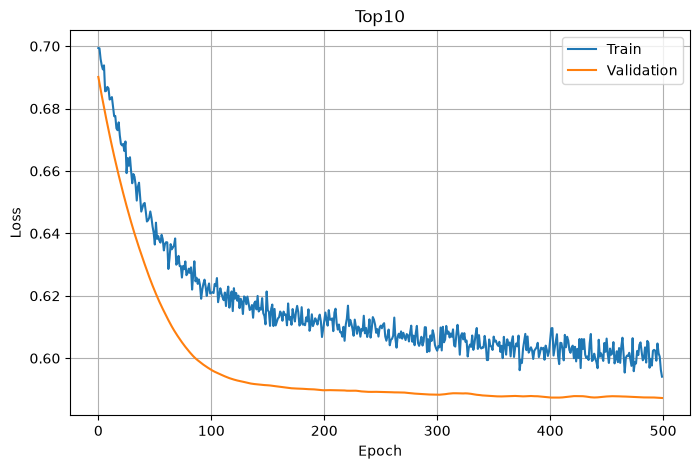

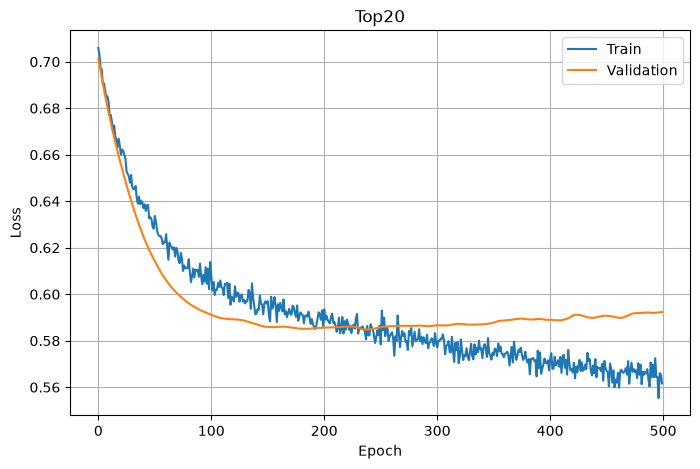

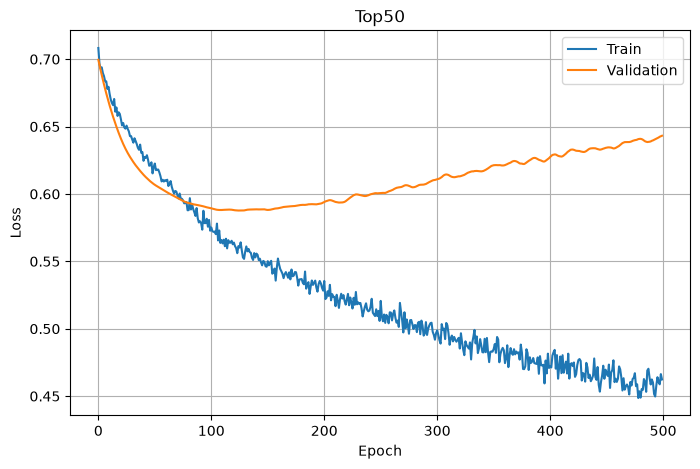

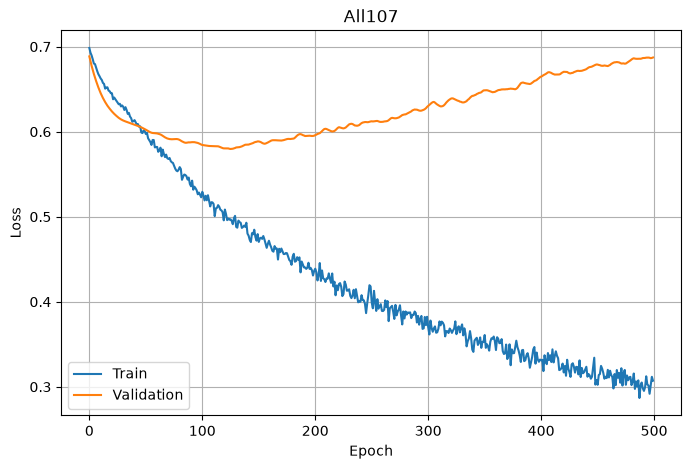

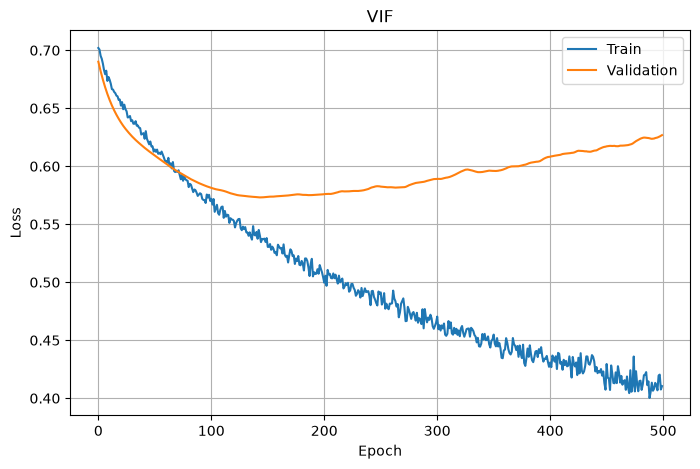

In [49]:
# Plot losses

import matplotlib.pyplot as plt

for name, result in results.items():

    plt.figure(figsize=(8,5))

    plt.plot(
        result["train_losses"],
        label="Train"
    )

    plt.plot(
        result["val_losses"],
        label="Validation"
    )

    plt.title(name)

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend()
    plt.grid(True)

    plt.show()